# 06 - Visualisation

Produces a final set of polished visualisations summarising the key 
findings of the Driver Performance Index across all five seasons.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

In [2]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')

dpi_df      = pd.read_csv(PROCESSED_DIR / 'dpi_final.csv')
cluster_df  = pd.read_csv(PROCESSED_DIR / 'driver_season_clustered.csv')

print("DPI data shape:",     dpi_df.shape)
print("Cluster data shape:", cluster_df.shape)

DPI data shape: (105, 24)
Cluster data shape: (105, 19)


## Chart 1 - DPI Score Distribution by Performance Tier


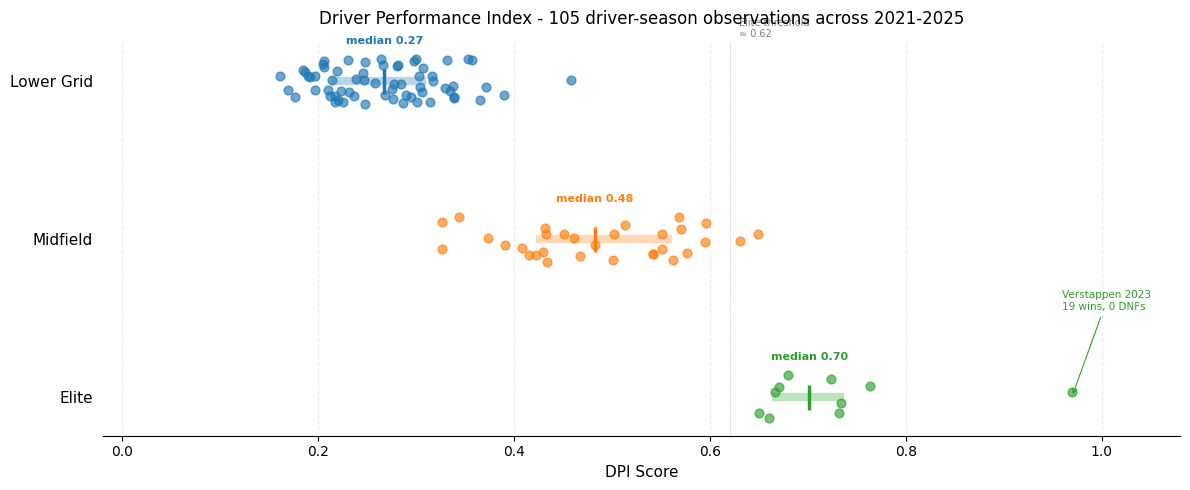

In [9]:
colour_map = {
    'Elite'      : '#2ca02c',
    'Midfield'   : '#ff7f0e',
    'Lower Grid' : '#1f77b4'
}

tier_order = ['Elite', 'Midfield', 'Lower Grid']

fig, ax = plt.subplots(figsize=(12, 5))

for i, tier in enumerate(tier_order):
    subset = dpi_df[dpi_df['cluster_label'] == tier]
    np.random.seed(42)
    jitter = np.random.uniform(-0.15, 0.15, size=len(subset))
    ax.scatter(
        subset['DPI'],
        np.full(len(subset), i) + jitter,
        color=colour_map[tier],
        alpha=0.65, s=40, zorder=3
    )
    q1, med, q3 = subset['DPI'].quantile([0.25, 0.5, 0.75])
    ax.plot([q1, q3], [i, i], color=colour_map[tier],
            linewidth=6, alpha=0.3, zorder=2)
    ax.plot(med, i, marker='|', color=colour_map[tier],
            markersize=18, markeredgewidth=2.5, zorder=4)
    ax.text(med, i + 0.22, f'median {med:.2f}',
            ha='center', va='bottom', fontsize=8,
            color=colour_map[tier], fontweight='bold')

ver23 = dpi_df[(dpi_df['driver_name'] == 'Max Verstappen') &
               (dpi_df['season'] == 2023)].iloc[0]
ax.annotate(
    'Verstappen 2023\n19 wins, 0 DNFs',
    xy=(ver23['DPI'], 0),
    xytext=(ver23['DPI'] - 0.01, 0.55),
    fontsize=7.5, color='#2ca02c',
    arrowprops=dict(arrowstyle='->', color='#2ca02c', lw=0.8)
)

ax.axvline(0.62, color='grey', linewidth=0.6,
           linestyle=':', alpha=0.6)
ax.text(0.63, 2.4, 'Elite threshold\n≈ 0.62',
        fontsize=7, color='grey', va='top')

ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels(tier_order, fontsize=11)
ax.set_xlabel('DPI Score', fontsize=11)
ax.set_title(
    'Driver Performance Index - 105 driver-season observations across 2021-2025',
    fontsize=12, pad=12
)
ax.set_xlim(-0.02, 1.08)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(axis='x', alpha=0.25, linestyle='--')
ax.tick_params(left=False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'dpi_distribution_by_tier.png', dpi=200, bbox_inches='tight')
plt.show()